In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [3]:
df = ev.build_results("results")

In [4]:
df

,A,A_1,A_1_conf,A_1_conf_error,A_1_error,A_2,A_2_conf,A_2_conf_error,A_2_error,A_3,...,E_1_conf_error,E_1_error,E_2,E_2_conf,E_2_conf_error,E_2_error,E_3,E_3_conf,E_3_conf_error,E_3_error
call_nr,,,,,,,,,,,,,,,,,,,,,
1,1,1,0.75,0.25,0,1,0.70,0.30,0,1,...,0.30,1,0,0.40,0.40,1,0,0.40,0.40,1
2,1,1,0.55,0.45,0,1,0.70,0.30,0,1,...,0.20,1,0,0.60,0.60,1,0,0.60,0.60,1
3,1,1,0.55,0.45,0,1,0.60,0.40,0,1,...,0.55,0,1,0.55,0.45,0,1,0.35,0.65,0
4,1,1,0.60,0.40,0,1,0.60,0.40,0,1,...,0.30,1,0,0.40,0.40,1,0,0.35,0.35,1
5,1,1,0.55,0.45,0,1,0.55,0.45,0,1,...,0.25,0,2,0.60,0.40,0,2,0.70,0.30,0
6,3,0,0.20,0.60,3,3,0.70,0.30,0,0,...,0.70,0,0,0.20,0.80,0,0,0.20,0.80,0
7,3,2,0.62,1.24,2,2,0.60,1.20,2,2,...,0.15,0,3,0.90,0.10,0,3,0.90,0.10,0
8,1,1,0.72,0.28,0,1,0.70,0.30,0,1,...,1.50,2,2,0.75,1.50,2,2,0.75,1.50,2
9,3,2,0.70,1.40,2,2,0.70,1.40,2,2,...,0.65,1,2,0.70,0.70,1,2,0.65,0.65,1


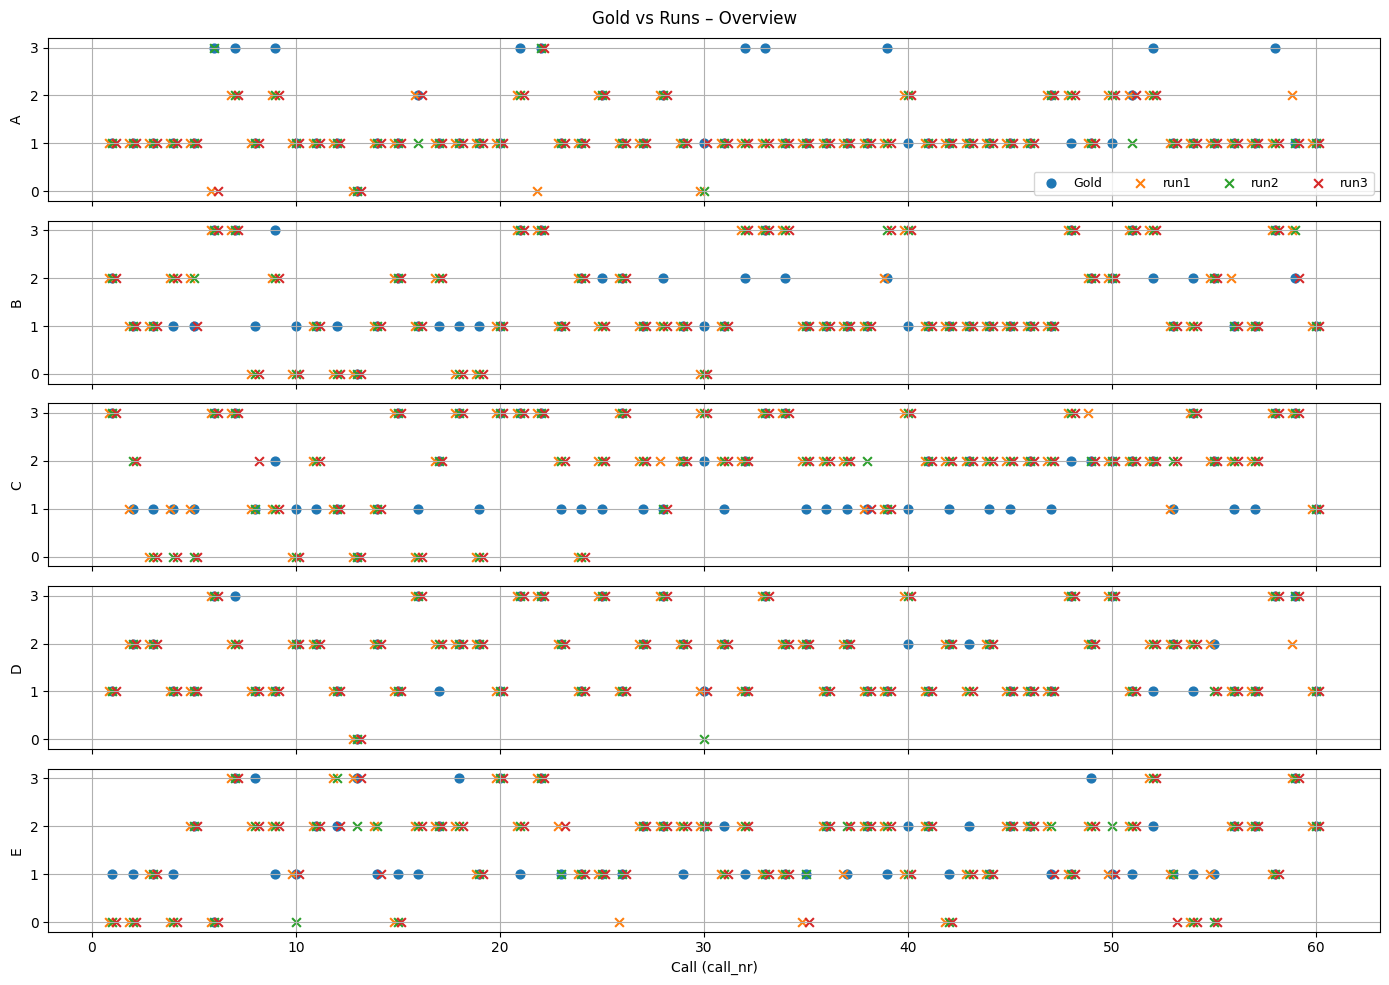

In [5]:
long_df = ev.wide_to_long_runs(df)
ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

In [6]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,conf_error,1,A,60,0.502833,0.300,30.17,0.687914
1,conf_error,1,B,60,0.375833,0.250,22.55,0.487211
2,conf_error,1,C,60,0.446167,0.450,26.77,0.497257
3,conf_error,1,D,60,0.355000,0.300,21.30,0.460796
4,conf_error,1,E,60,0.503333,0.450,30.20,0.589491
5,conf_error,2,A,60,0.512167,0.300,30.73,0.745148
6,conf_error,2,B,60,0.382500,0.275,22.95,0.498051
7,conf_error,2,C,60,0.411833,0.425,24.71,0.461218
8,conf_error,2,D,60,0.327333,0.270,19.64,0.403444
9,conf_error,2,E,60,0.543333,0.500,32.60,0.638036


In [7]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.502833,0.375833,0.446167,0.355000,0.503333
2,0.512167,0.382500,0.411833,0.327333,0.543333
3,0.510833,0.368167,0.405833,0.341500,0.506333


In [8]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.516667,0.350000,0.433333,0.150000,0.483333
2,0.433333,0.350000,0.483333,0.150000,0.533333
3,0.433333,0.316667,0.483333,0.133333,0.466667


In [9]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,conf_error,1,300,0.436633,130.99,2.10
1,conf_error,2,300,0.435433,130.63,2.25
2,conf_error,3,300,0.426533,127.96,2.25
3,error,1,300,0.386667,116.00,3.00
4,error,2,300,0.390000,117.00,3.00
5,error,3,300,0.366667,110.00,3.00


In [10]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,116,130.99
1,2,117,130.63
2,3,110,127.96


In [11]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.461111,83,0.508611,91.55
1,B,0.338889,61,0.375500,67.59
2,C,0.466667,84,0.421278,75.83
3,D,0.144444,26,0.341278,61.43
4,E,0.494444,89,0.517667,93.18
